<a href="https://www.kaggle.com/code/lalit7881/oil-seeds-production-yield-analysis?scriptVersionId=303622516" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ranamuhammmadusman/oil-seeds-dataset-production-and-yield-analysis/oil_seeds_punjab_agricultural_data.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ranamuhammmadusman/oil-seeds-dataset-production-and-yield-analysis/oil_seeds_punjab_agricultural_data.csv")

In [3]:
df.head()

,Year,Crop_Name,Crop_Type,District_Name,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Season,Temperature_Celsius_Avg,Rainfall_MM,Irrigation_Requirement_MM,Soil_Type,Market_Price_PKR_Per_Kg,Export_Status,Quality_Grade,Purity_Percent
0,2020,Sunflower,Oilseed,Okara,12500,18750,1500,Spring,32.5,425,250,Sandy Loam,65,Exported,A,96.2
1,2020,Sunflower,Oilseed,Jhang,11200,16240,1450,Spring,31.8,390,260,Loamy,63,Exported,A,95.8
2,2020,Sunflower,Oilseed,Faisalabad,15000,22500,1500,Spring,33.2,410,240,Sandy Loam,65,Exported,A,96.5
3,2020,Sunflower,Oilseed,Sahiwal,8900,11680,1312,Spring,32.1,380,270,Loamy,62,Local Market,B,94.2
4,2020,Sunflower,Oilseed,Gujranwala,7500,9750,1300,Spring,31.5,415,265,Clay Loam,60,Local Market,B,93.8


In [4]:
df.tail()

,Year,Crop_Name,Crop_Type,District_Name,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Season,Temperature_Celsius_Avg,Rainfall_MM,Irrigation_Requirement_MM,Soil_Type,Market_Price_PKR_Per_Kg,Export_Status,Quality_Grade,Purity_Percent
73,2025,Rape Seed,Oilseed,Sialkot,5000,4000,800,Winter,19.7,750,150,Sandy Loam,152,Exported,A,99.7
74,2025,Rape Seed,Oilseed,Gujrat,3500,2800,800,Winter,19.4,720,160,Loamy,148,Local Market,B,98.3
75,2025,Gram,Pulse,Okara,11000,10450,950,Winter,21.0,670,120,Sandy Loam,128,Exported,A,98.6
76,2025,Gram,Pulse,Kasur,9400,8930,950,Winter,21.3,680,110,Loamy,129,Exported,A,98.9
77,2025,Gram,Pulse,Sialkot,6700,5695,850,Winter,18.7,730,100,Clay Loam,124,Local Market,B,97.1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       78 non-null     int64  
 1   Crop_Name                  78 non-null     object 
 2   Crop_Type                  78 non-null     object 
 3   District_Name              78 non-null     object 
 4   Area_Hectares              78 non-null     int64  
 5   Production_Tonnes          78 non-null     int64  
 6   Yield_Kg_Per_Hectare       78 non-null     int64  
 7   Season                     78 non-null     object 
 8   Temperature_Celsius_Avg    78 non-null     float64
 9   Rainfall_MM                78 non-null     int64  
 10  Irrigation_Requirement_MM  78 non-null     int64  
 11  Soil_Type                  78 non-null     object 
 12  Market_Price_PKR_Per_Kg    78 non-null     int64  
 13  Export_Status              78 non-null     object 
 

In [6]:
df.describe()

,Year,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Temperature_Celsius_Avg,Rainfall_MM,Irrigation_Requirement_MM,Market_Price_PKR_Per_Kg,Purity_Percent
count,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000
mean,2022.500000,12116.666667,18833.205128,1338.615385,28.273077,510.320513,219.615385,90.679487,97.011538
std,1.718879,6750.688597,15350.553334,441.423825,7.283047,135.743120,77.420966,27.957061,1.335332
min,2020.000000,2100.000000,1680.000000,800.000000,17.200000,280.000000,100.000000,44.000000,93.800000
25%,2021.000000,7575.000000,7505.000000,950.000000,19.800000,402.500000,150.000000,68.500000,96.200000
50%,2022.500000,10900.000000,13650.000000,1300.000000,32.450000,470.000000,250.000000,86.000000,97.100000
75%,2024.000000,15575.000000,26625.000000,1500.000000,34.100000,650.000000,270.000000,114.250000,98.000000
max,2025.000000,29500.000000,59000.000000,2000.000000,36.700000,750.000000,320.000000,152.000000,99.700000


In [7]:
df.isnull().sum()

Year                         0
Crop_Name                    0
Crop_Type                    0
District_Name                0
Area_Hectares                0
Production_Tonnes            0
Yield_Kg_Per_Hectare         0
Season                       0
Temperature_Celsius_Avg      0
Rainfall_MM                  0
Irrigation_Requirement_MM    0
Soil_Type                    0
Market_Price_PKR_Per_Kg      0
Export_Status                0
Quality_Grade                0
Purity_Percent               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Year                           int64
Crop_Name                     object
Crop_Type                     object
District_Name                 object
Area_Hectares                  int64
Production_Tonnes              int64
Yield_Kg_Per_Hectare           int64
Season                        object
Temperature_Celsius_Avg      float64
Rainfall_MM                    int64
Irrigation_Requirement_MM      int64
Soil_Type                     object
Market_Price_PKR_Per_Kg        int64
Export_Status                 object
Quality_Grade                 object
Purity_Percent               float64
dtype: object

In [10]:
df.shape

(78, 16)

In [11]:
df.columns

Index(['Year', 'Crop_Name', 'Crop_Type', 'District_Name', 'Area_Hectares',
       'Production_Tonnes', 'Yield_Kg_Per_Hectare', 'Season',
       'Temperature_Celsius_Avg', 'Rainfall_MM', 'Irrigation_Requirement_MM',
       'Soil_Type', 'Market_Price_PKR_Per_Kg', 'Export_Status',
       'Quality_Grade', 'Purity_Percent'],
      dtype='object')

In [12]:
df.nunique()

Year                          6
Crop_Name                     4
Crop_Type                     2
District_Name                11
Area_Hectares                67
Production_Tonnes            76
Yield_Kg_Per_Hectare          8
Season                        3
Temperature_Celsius_Avg      55
Rainfall_MM                  55
Irrigation_Requirement_MM    13
Soil_Type                     4
Market_Price_PKR_Per_Kg      55
Export_Status                 2
Quality_Grade                 2
Purity_Percent               43
dtype: int64

## Data visualization

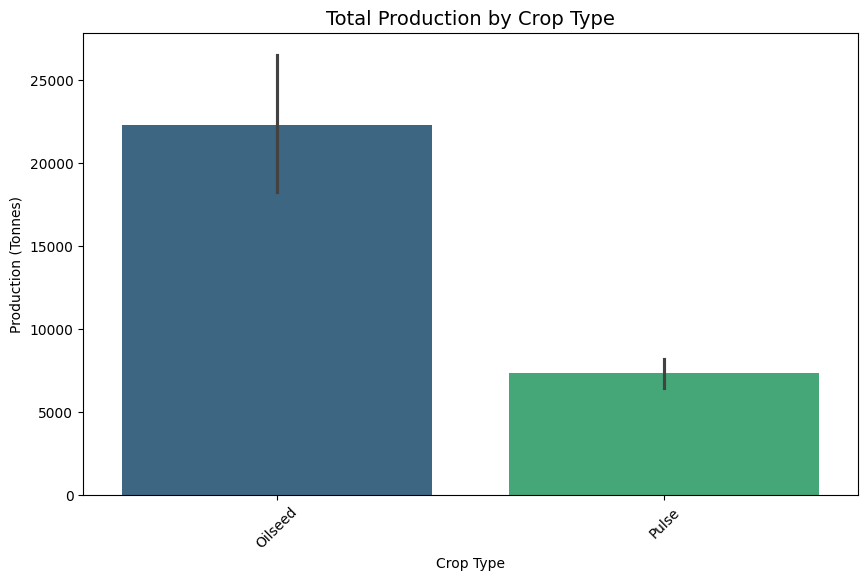

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Crop_Type',
    y='Production_Tonnes',
    palette='viridis'
)

plt.title("Total Production by Crop Type", fontsize=14)
plt.xlabel("Crop Type")
plt.ylabel("Production (Tonnes)")
plt.xticks(rotation=45)

plt.show()

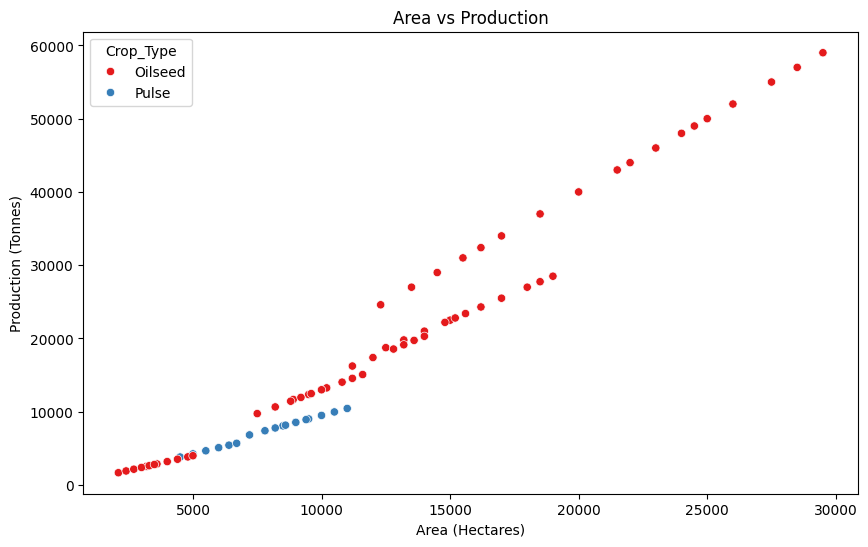

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Area_Hectares',
    y='Production_Tonnes',
    hue='Crop_Type',
    palette='Set1'
)

plt.title("Area vs Production")
plt.xlabel("Area (Hectares)")
plt.ylabel("Production (Tonnes)")

plt.show()

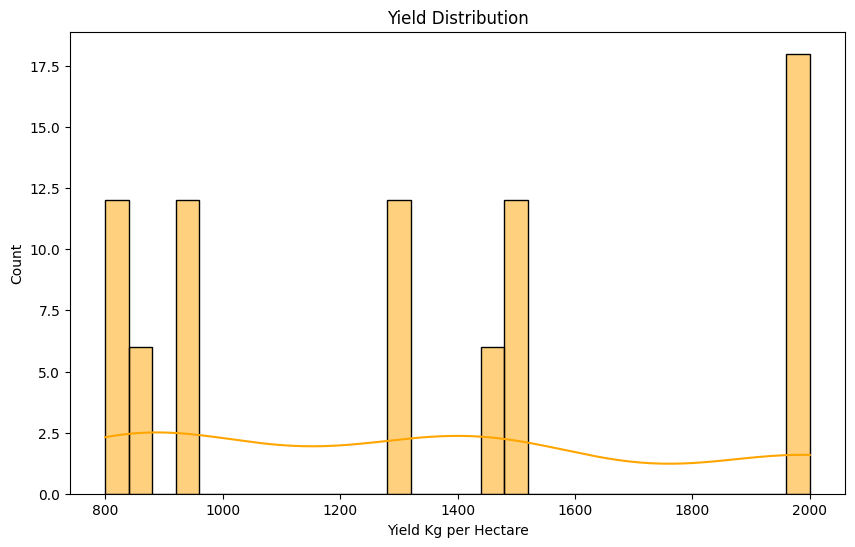

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Yield_Kg_Per_Hectare'],
    bins=30,
    color='orange',
    kde=True
)

plt.title("Yield Distribution")
plt.xlabel("Yield Kg per Hectare")

plt.show()

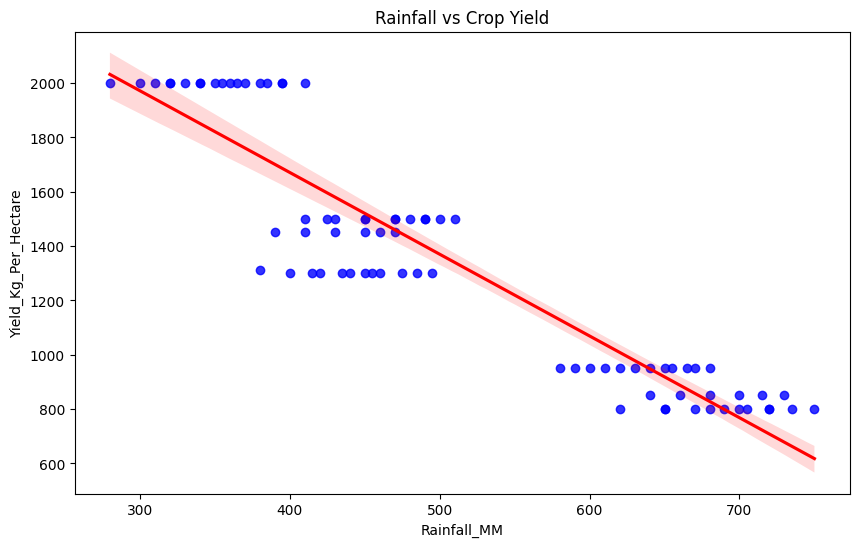

In [16]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='Rainfall_MM',
    y='Yield_Kg_Per_Hectare',
    scatter_kws={'color':'blue'},
    line_kws={'color':'red'}
)

plt.title("Rainfall vs Crop Yield")

plt.show()

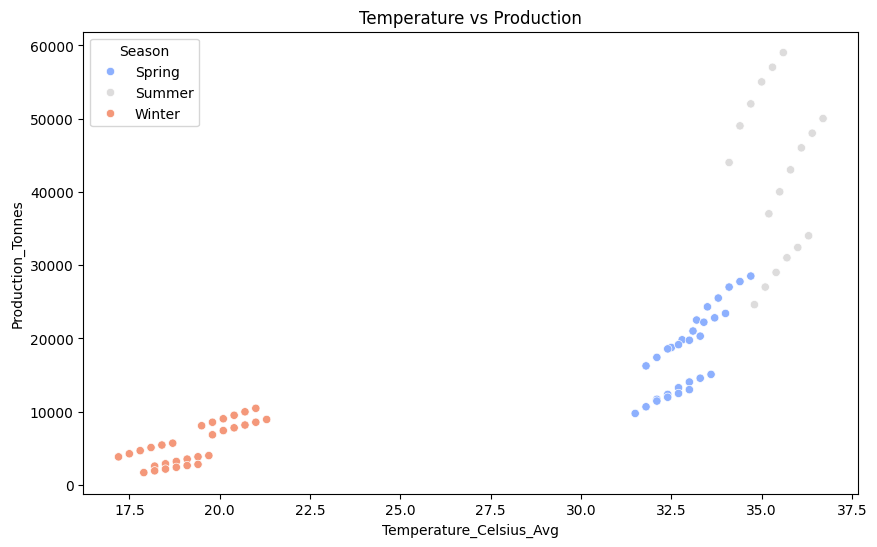

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Temperature_Celsius_Avg',
    y='Production_Tonnes',
    hue='Season',
    palette='coolwarm'
)

plt.title("Temperature vs Production")

plt.show()

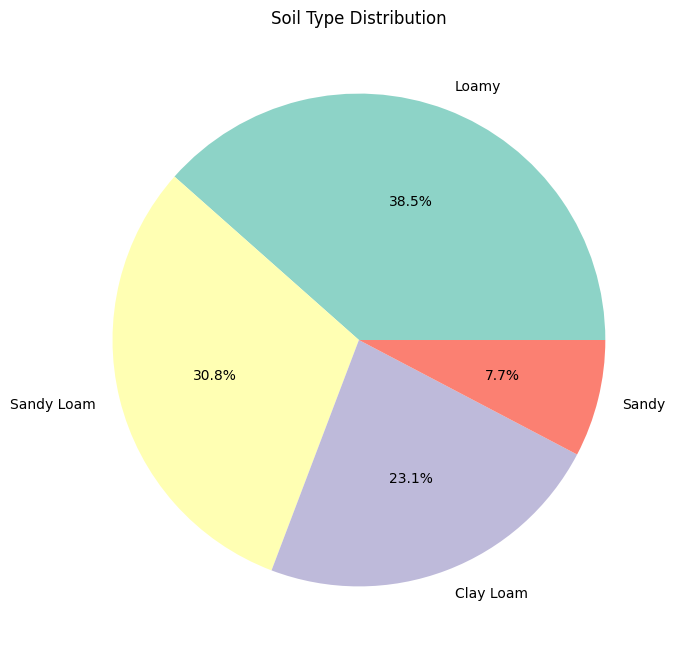

In [18]:
soil_counts = df['Soil_Type'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    soil_counts,
    labels=soil_counts.index,
    autopct='%1.1f%%',
    colors=plt.cm.Set3.colors
)

plt.title("Soil Type Distribution")

plt.show()

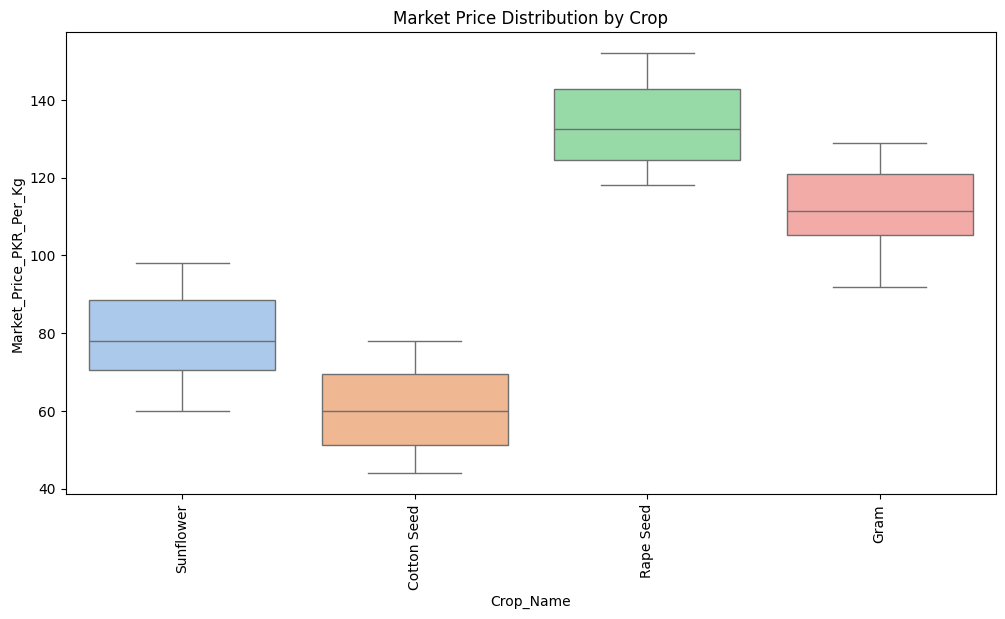

In [19]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Crop_Name',
    y='Market_Price_PKR_Per_Kg',
    palette='pastel'
)

plt.xticks(rotation=90)

plt.title("Market Price Distribution by Crop")

plt.show()

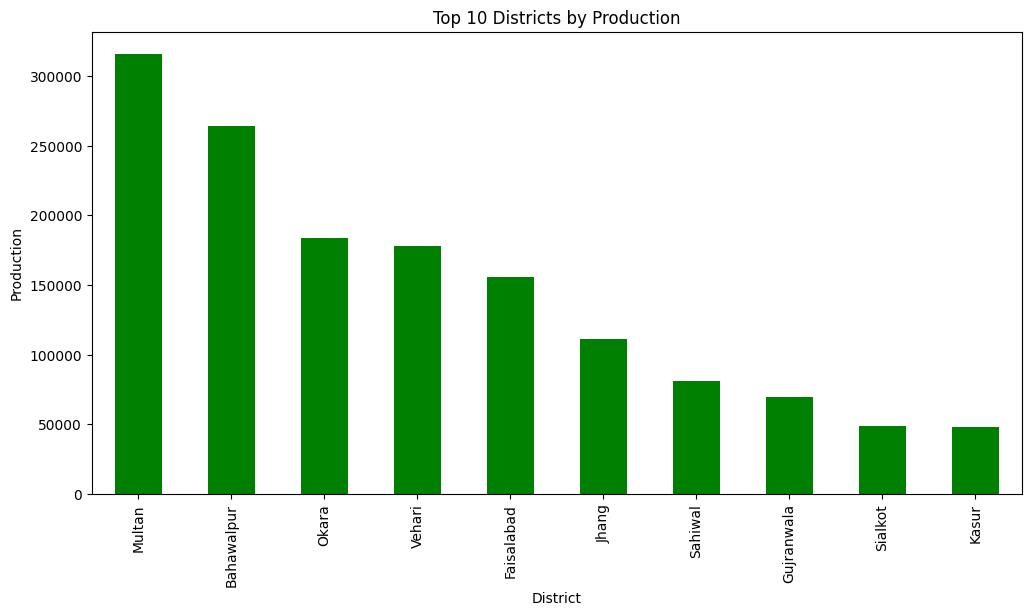

In [20]:
top_districts = df.groupby('District_Name')['Production_Tonnes'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_districts.plot(
    kind='bar',
    color='green'
)

plt.title("Top 10 Districts by Production")
plt.xlabel("District")
plt.ylabel("Production")

plt.show()

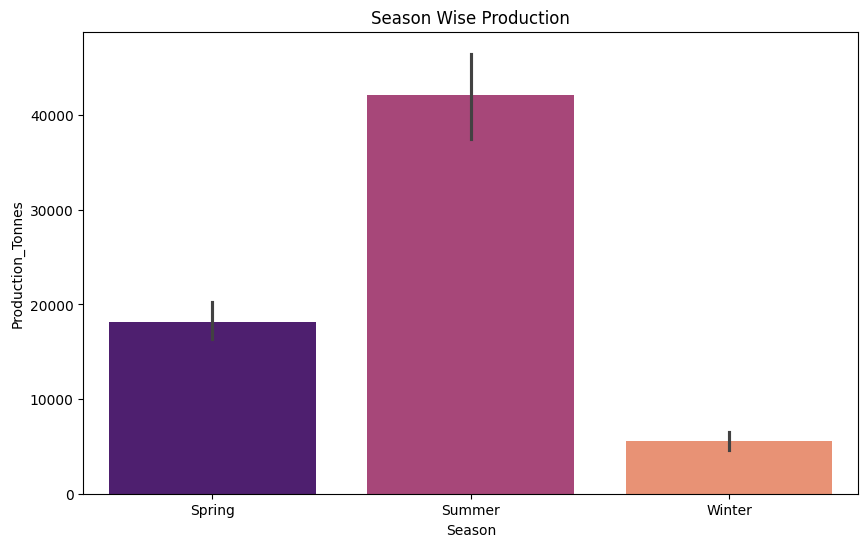

In [21]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Season',
    y='Production_Tonnes',
    palette='magma'
)

plt.title("Season Wise Production")

plt.show()

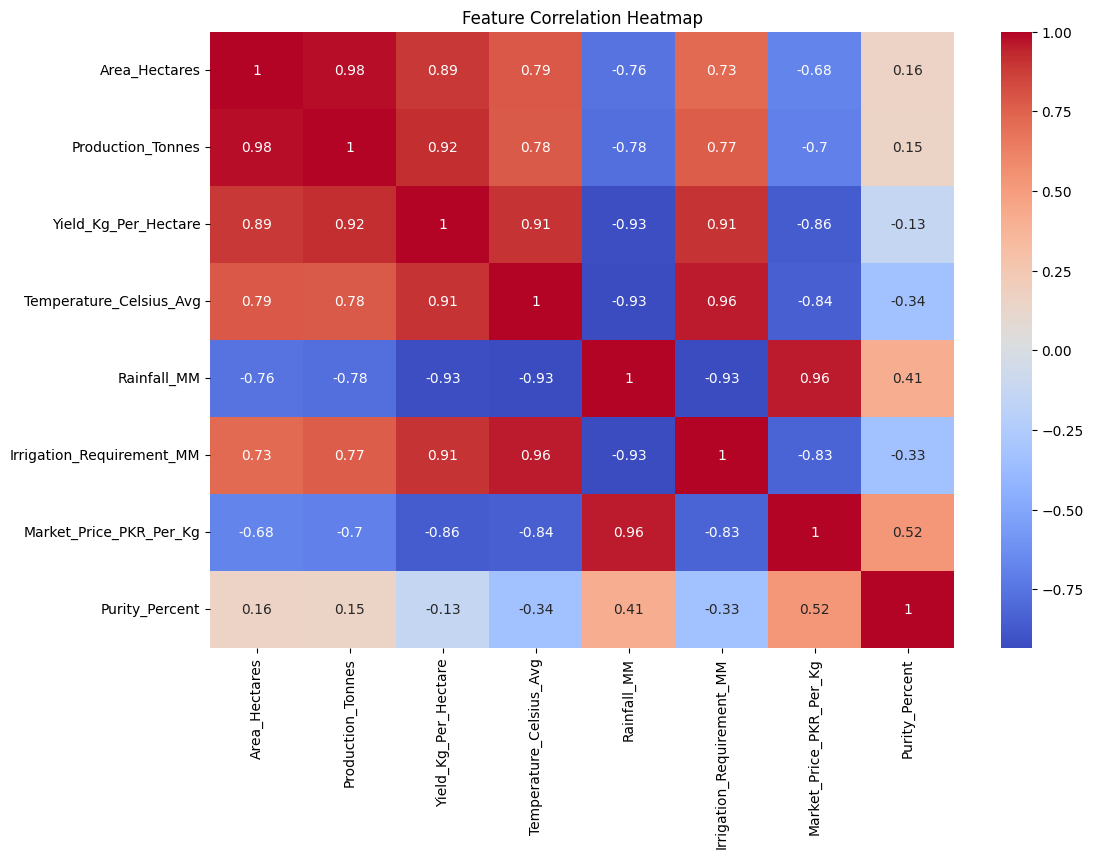

In [22]:
plt.figure(figsize=(12,8))

numeric_cols = [
    'Area_Hectares','Production_Tonnes','Yield_Kg_Per_Hectare',
    'Temperature_Celsius_Avg','Rainfall_MM',
    'Irrigation_Requirement_MM','Market_Price_PKR_Per_Kg',
    'Purity_Percent'
]

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

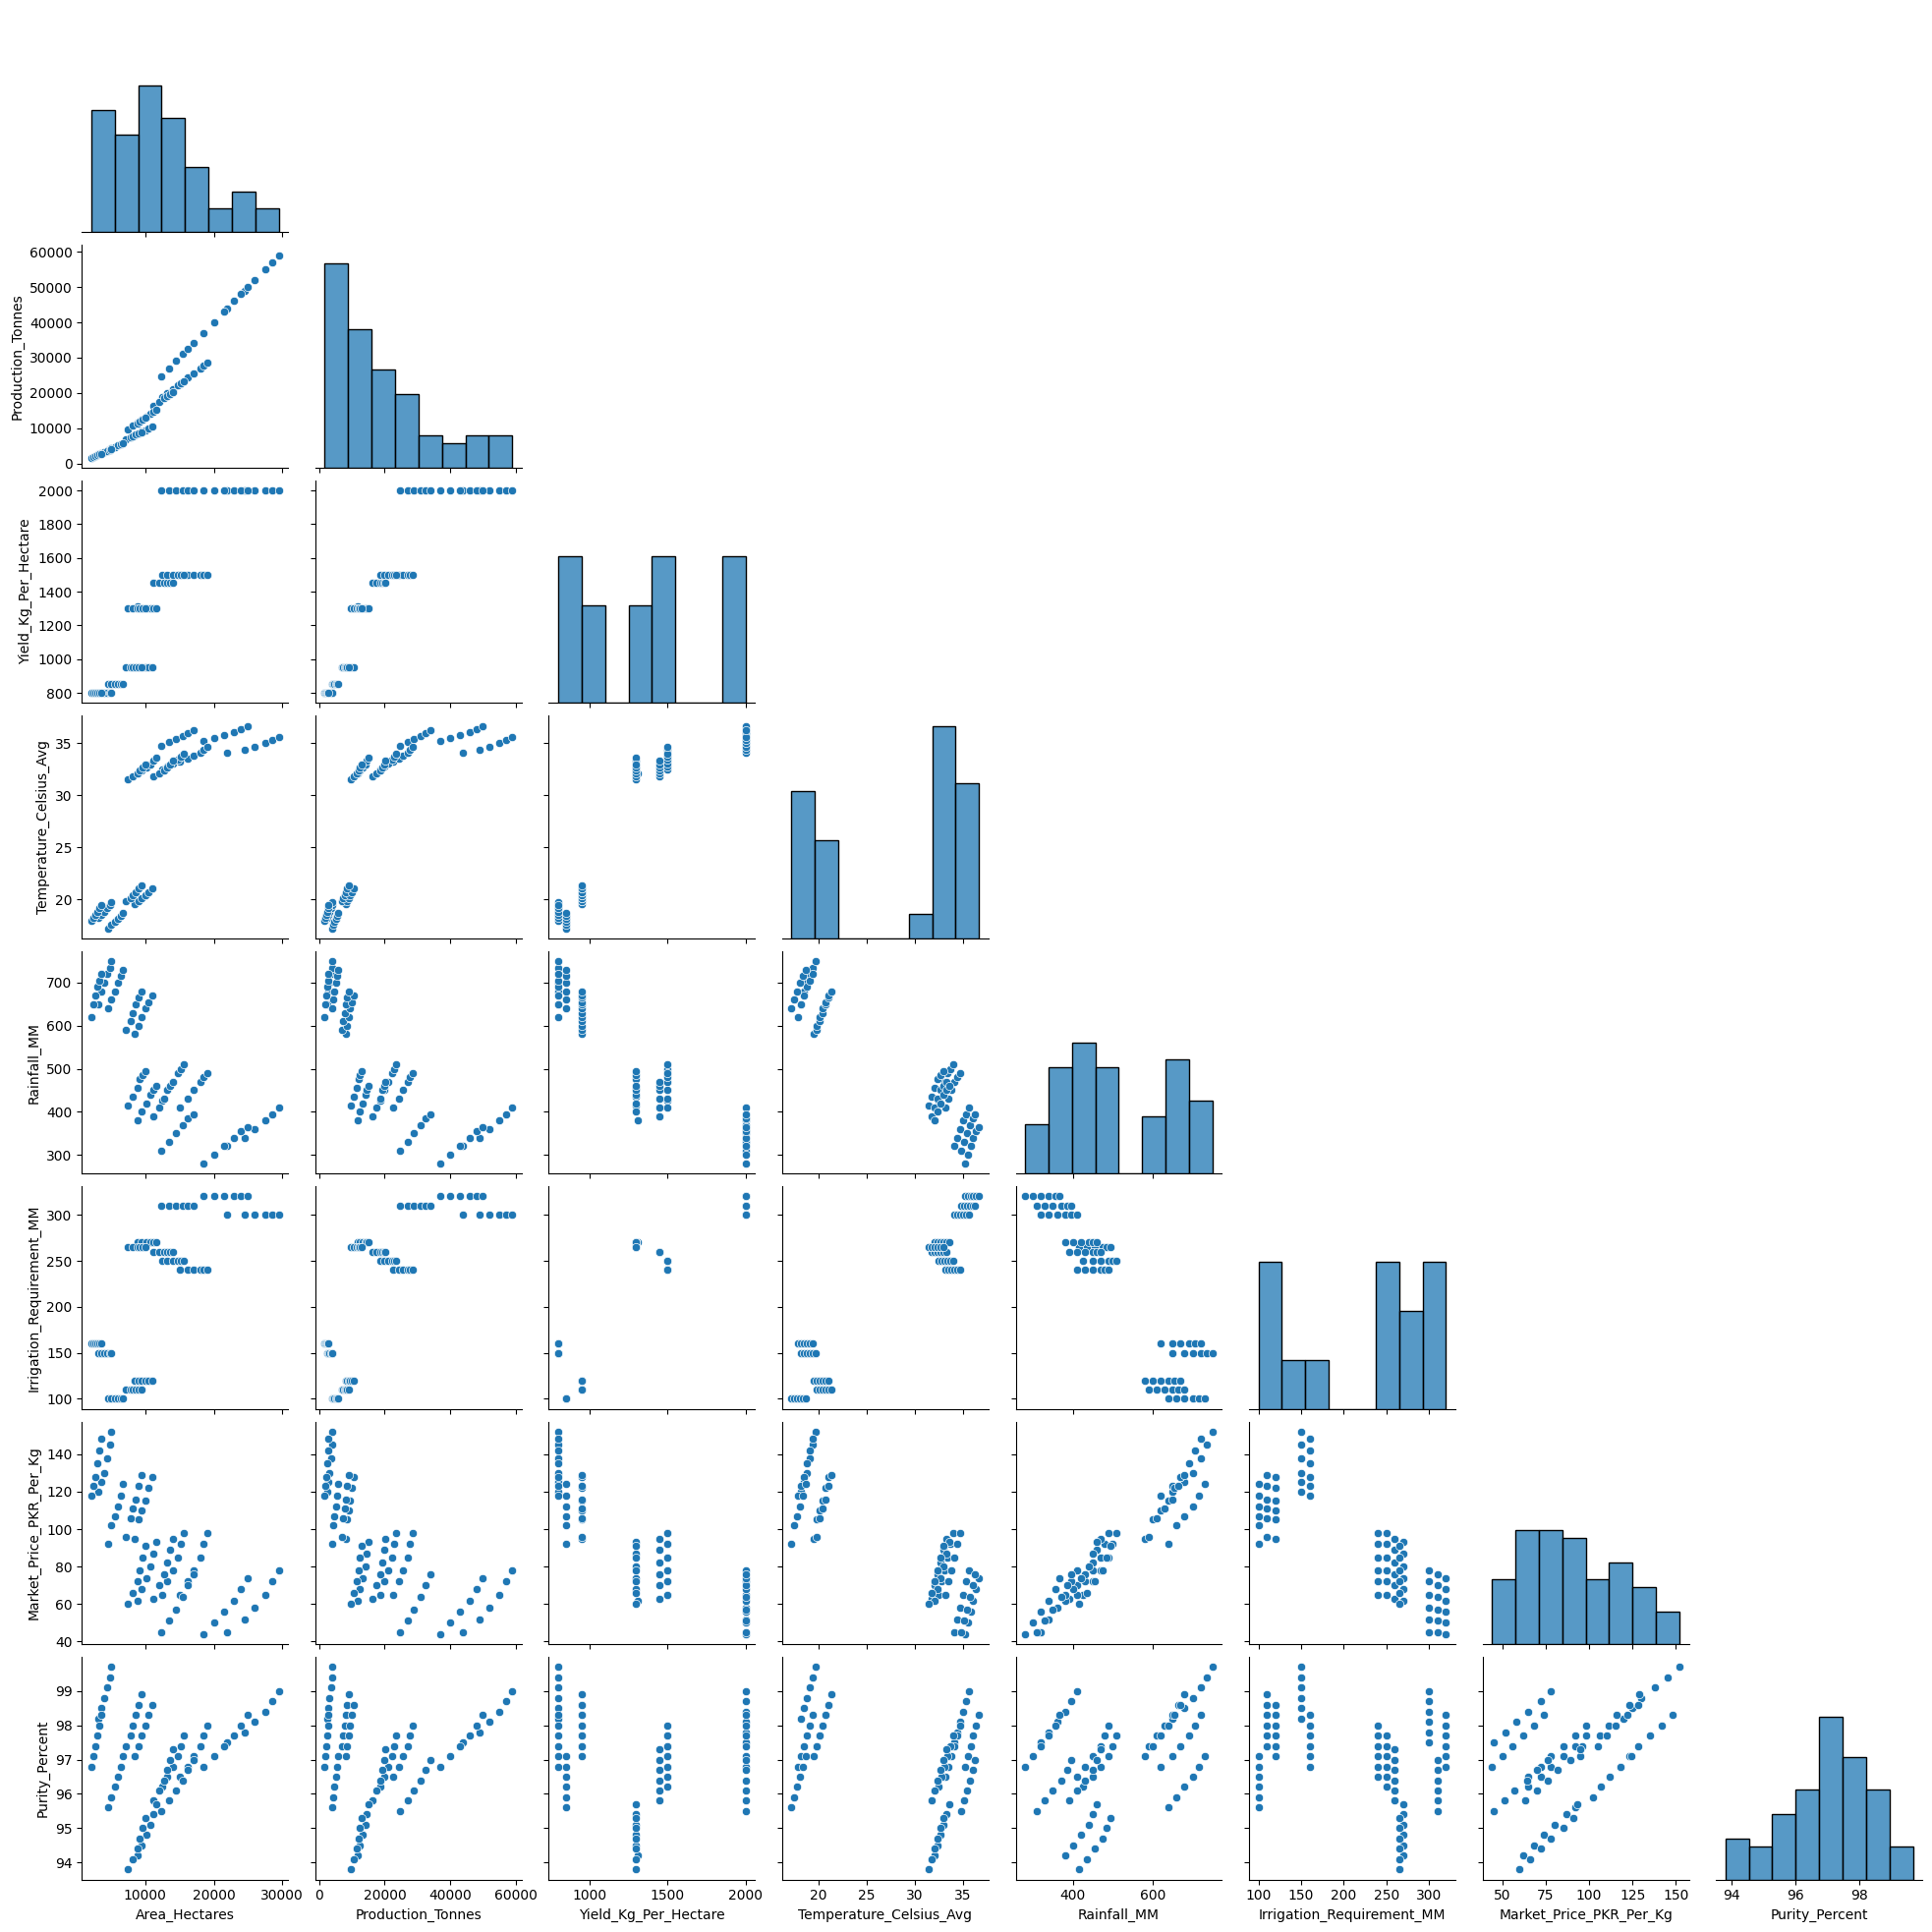

In [23]:
sns.pairplot(df[numeric_cols], corner=True)
plt.show()

## Feature engineering

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [25]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [26]:
X = df_encoded.drop("Production_Tonnes", axis=1)
y = df_encoded["Production_Tonnes"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(),

    "Random Forest": RandomForestRegressor(),

    "Support Vector Machine": SVR(),

    "KNN": KNeighborsRegressor(),

    "Gradient Boosting": GradientBoostingRegressor()
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = r2

    print(name)
    print("R2 Score:", r2)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("-----------------------")

Linear Regression
R2 Score: 0.9997762085666119
MAE: 188.50277967121178
RMSE: 241.08484592288013
-----------------------
Decision Tree
R2 Score: 0.9886372387869017
MAE: 1351.25
RMSE: 1717.869319826162
-----------------------
Random Forest
R2 Score: 0.9894511145232208
MAE: 1014.0500000000002
RMSE: 1655.2037903231133
-----------------------
Support Vector Machine
R2 Score: -0.055436384888876145
MAE: 12891.520586706221
RMSE: 16556.33534550777
-----------------------
KNN
R2 Score: 0.9885752866482493
MAE: 1413.75
RMSE: 1722.5460443773338
-----------------------
Gradient Boosting
R2 Score: 0.9975329244403811
MAE: 482.83739607298736
RMSE: 800.4595840828364
-----------------------


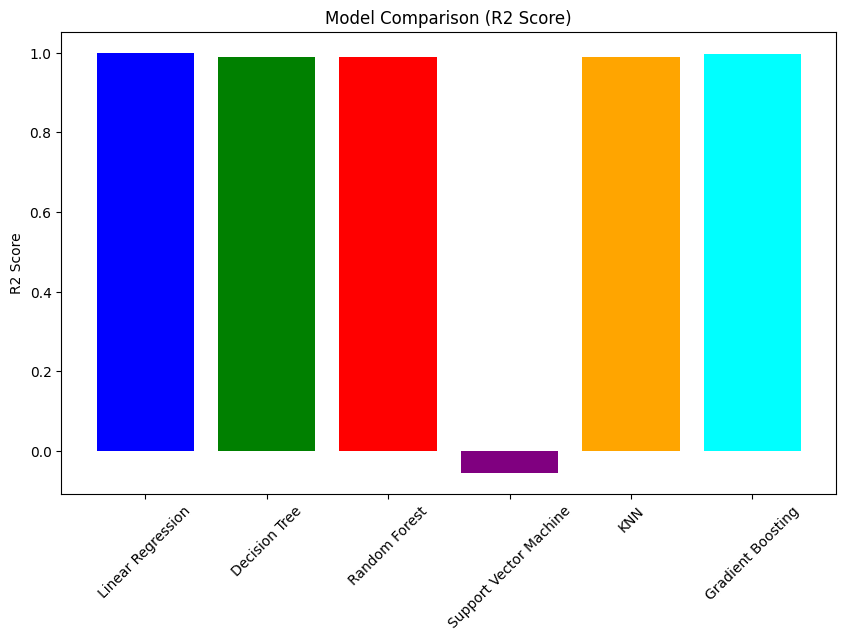

In [30]:
plt.figure(figsize=(10,6))

plt.bar(results.keys(), results.values(), color=['blue','green','red','purple','orange','cyan'])

plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)

plt.show()

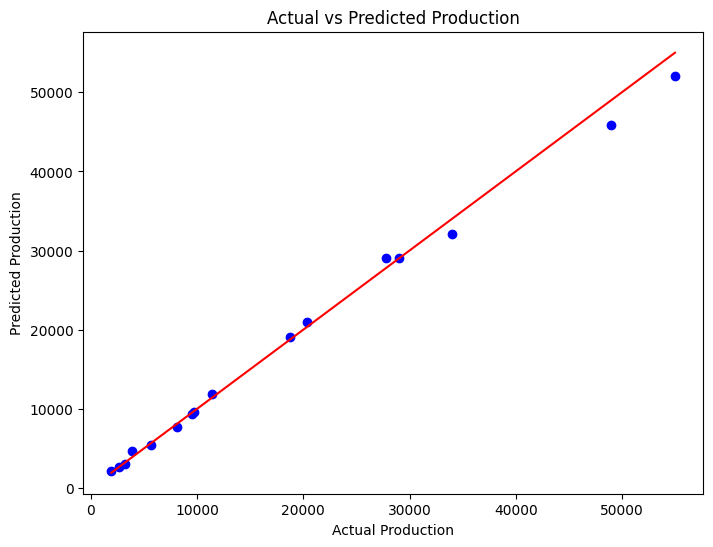

In [31]:
best_model = RandomForestRegressor()

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, color="blue")

plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")

plt.title("Actual vs Predicted Production")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

In [32]:
median_value = df_encoded["Production_Tonnes"].median()

df_encoded["Production_Class"] = (df_encoded["Production_Tonnes"] > median_value).astype(int)

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

X = df_encoded.drop(["Production_Tonnes","Production_Class"], axis=1)
y = df_encoded["Production_Class"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

clf = RandomForestClassifier()

clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:,1]

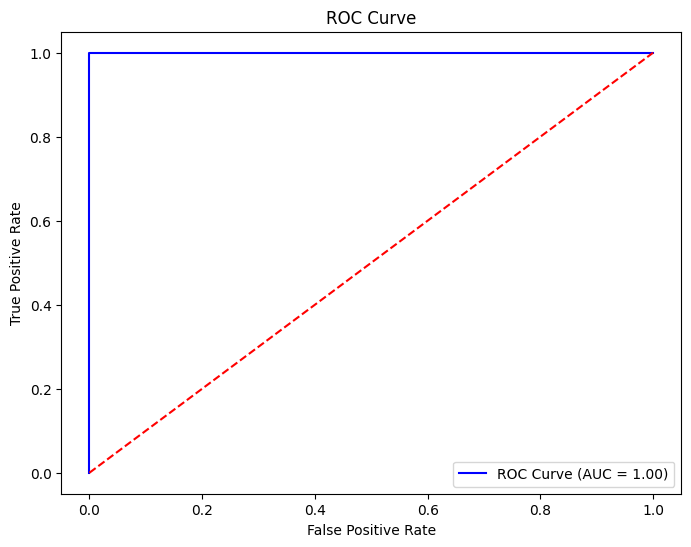

In [34]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, color='blue', label='ROC Curve (AUC = %0.2f)' % roc_auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Thank you..pls upvote!!!!!!!!